# RNA para classificação e regressão - Student Habits vs Academic Performance

Este notebook mantém os dois conceitos separados:

1. **Classificação**: prever a classe nominal `score_class` (`Baixo`, `Medio`, `Alto`).
2. **Regressão**: prever a nota numérica `exam_score`.

A classificação é útil quando o objetivo é categorizar o desempenho do aluno. A regressão é usada quando o objetivo é prever a nota do aluno em pontos.

In [1]:
# 1. Imports e configurações
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.dummy import DummyClassifier, DummyRegressor

plt.rcParams.update({'figure.max_open_warning': 0})
RANDOM_STATE = 42

In [2]:
# 2. Pastas e carregamento do dataset
BASE_DIR = Path('.')
DATA_PATH = BASE_DIR / 'dados' / 'student_habits_performance.csv'
IMG_DIR = BASE_DIR / 'imagens'
MODEL_DIR = BASE_DIR / 'modelos'
REL_DIR = BASE_DIR / 'relatorios'

IMG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
REL_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
# 3. Visão geral do dataset
print('Quantidade de registros:', df.shape[0])
print('Quantidade de colunas:', df.shape[1])
print('\nColunas:')
print(df.columns.tolist())

print('\nTipos de dados:')
print(df.dtypes)

print('\nValores ausentes por coluna:')
print(df.isnull().sum())

Quantidade de registros: 1000
Quantidade de colunas: 16

Colunas:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

Tipos de dados:
student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     o

## Preparação comum dos dados

A coluna `student_id` é apenas identificadora e não deve entrar no treinamento. As colunas `exam_score` e `score_class` serão usadas como alvos, dependendo da tarefa.

Para a tarefa de classificação, a variável `score_class` é criada a partir da nota:

- `Baixo`: nota menor que 60
- `Medio`: nota maior ou igual a 60 e menor que 80
- `Alto`: nota maior ou igual a 80

In [4]:
# 4. Criação da classe para a tarefa de classificação

def criar_score_class(score):
    if score < 60:
        return 'Baixo'
    elif score < 80:
        return 'Medio'
    else:
        return 'Alto'

df['score_class'] = df['exam_score'].apply(criar_score_class)

ordem_classes = ['Baixo', 'Medio', 'Alto']
print(df['score_class'].value_counts().reindex(ordem_classes))

score_class
Baixo    280
Medio    443
Alto     277
Name: count, dtype: int64


In [5]:
# 5. Separação das entradas e dos alvos
X = df.drop(columns=['student_id', 'exam_score', 'score_class'])
y_class = df['score_class']       # alvo da classificação
y_reg = df['exam_score']          # alvo da regressão

colunas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

print('Colunas numéricas:', colunas_numericas)
print('Colunas categóricas:', colunas_categoricas)

Colunas numéricas: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Colunas categóricas: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [6]:
# 6. Divisão entre treino e teste
# O mesmo conjunto de teste será usado nos dois problemas apenas para facilitar a organização.
# A estratificação usa y_class para manter a proporção das classes no treino e teste.
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_class,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_class
)

print('Treino:', X_train.shape[0])
print('Teste:', X_test.shape[0])

Treino: 800
Teste: 200


In [7]:
# 7. Função para criar o pré-processamento
# Numéricas: mediana + padronização
# Categóricas: moda + One-Hot Encoding

def criar_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def criar_preprocessador():
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', criar_one_hot_encoder())
    ])

    preprocessador = ColumnTransformer(transformers=[
        ('num', numeric_transformer, colunas_numericas),
        ('cat', categorical_transformer, colunas_categoricas)
    ])

    return preprocessador

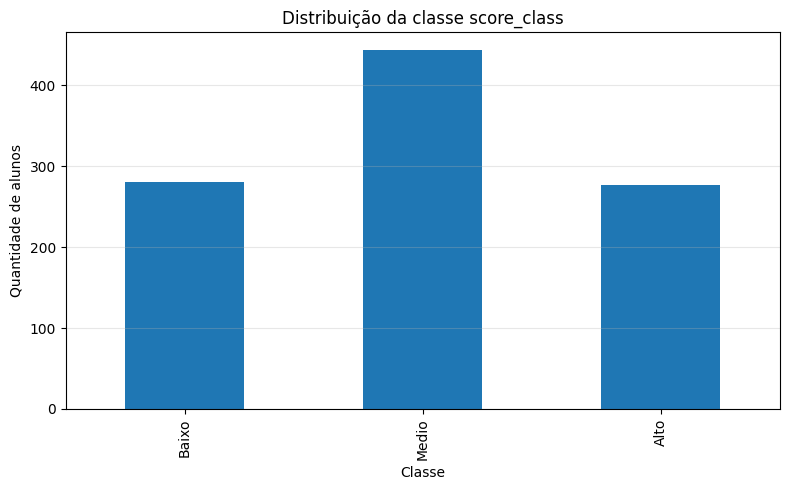

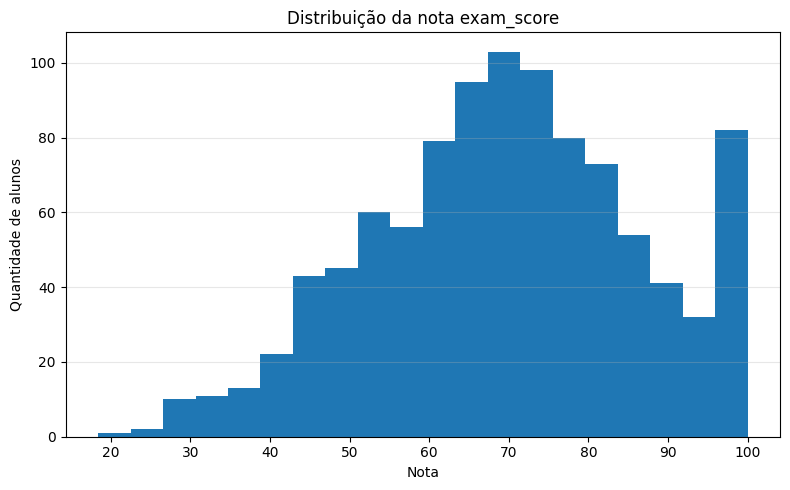

In [8]:
# 8. Gráficos iniciais do dataset
plt.figure(figsize=(8, 5))
df['score_class'].value_counts().reindex(ordem_classes).plot(kind='bar')
plt.title('Distribuição da classe score_class')
plt.xlabel('Classe')
plt.ylabel('Quantidade de alunos')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '01_distribuicao_score_class.png', dpi=160)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df['exam_score'], bins=20)
plt.title('Distribuição da nota exam_score')
plt.xlabel('Nota')
plt.ylabel('Quantidade de alunos')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '02_distribuicao_exam_score.png', dpi=160)
plt.show()

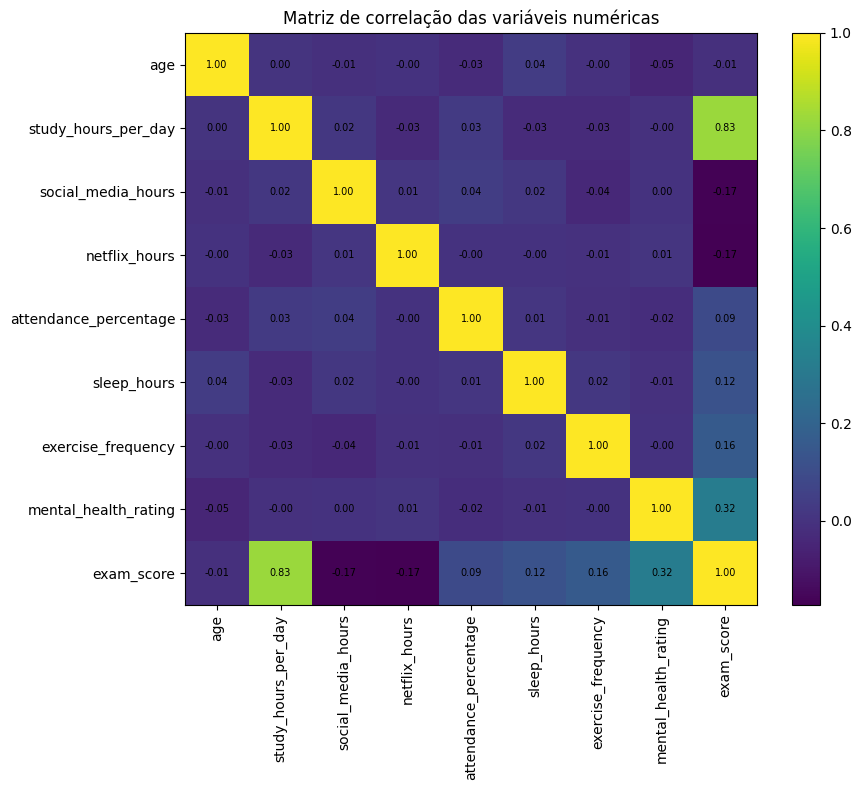

In [9]:
# 9. Matriz de correlação das variáveis numéricas
num_df = df.drop(columns=['score_class']).select_dtypes(include=[np.number])
corr = num_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr)
ax.set_title('Matriz de correlação das variáveis numéricas')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(IMG_DIR / '03_matriz_correlacao.png', dpi=160)
plt.show()

# Parte A - RNA para classificação

Nesta parte, a RNA será usada como **classificadora**. O alvo é `score_class`, uma variável nominal criada a partir da nota.

Aqui a saída esperada do modelo é uma classe: `Baixo`, `Medio` ou `Alto`.

In [10]:
# 10. Modelo de classificação com RNA
rna_classificadora = Pipeline(steps=[
    ('preprocessamento', criar_preprocessador()),
    ('modelo', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=1500,
        early_stopping=False,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=RANDOM_STATE
    ))
])

baseline_classificacao = DummyClassifier(strategy='most_frequent')

baseline_classificacao.fit(X_train, y_class_train)
rna_classificadora.fit(X_train, y_class_train)

pred_class_baseline = baseline_classificacao.predict(X_test)
pred_class_rna = rna_classificadora.predict(X_test)

print('Treinamento da RNA classificadora concluído.')

Treinamento da RNA classificadora concluído.


In [11]:
# 11. Métricas da classificação

def calcular_metricas_classificacao(nome, y_true, y_pred):
    return {
        'modelo': nome,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

metricas_classificacao = pd.DataFrame([
    calcular_metricas_classificacao('Baseline - classe majoritária', y_class_test, pred_class_baseline),
    calcular_metricas_classificacao('RNA Classificadora - MLPClassifier', y_class_test, pred_class_rna)
])

metricas_classificacao.to_csv('metricas_classificacao.csv', index=False)
metricas_classificacao

,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,Baseline - classe majoritária,0.445,0.148333,0.333333,0.205306
1,RNA Classificadora - MLPClassifier,0.830,0.836198,0.831958,0.833998


In [12]:
# 12. Relatório detalhado da classificação
relatorio_classificacao = classification_report(
    y_class_test,
    pred_class_rna,
    labels=ordem_classes,
    zero_division=0
)
print(relatorio_classificacao)

with open(REL_DIR / 'relatorio_classificacao_rna.txt', 'w', encoding='utf-8') as arquivo:
    arquivo.write(relatorio_classificacao)

              precision    recall  f1-score   support

       Baixo       0.85      0.84      0.85        56
       Medio       0.80      0.82      0.81        89
        Alto       0.85      0.84      0.84        55

    accuracy                           0.83       200
   macro avg       0.84      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



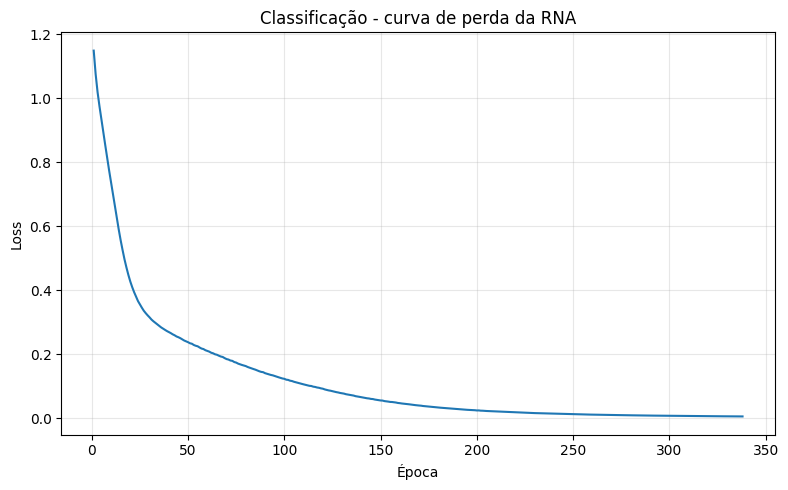

In [13]:
# 13. Curva de perda da classificação
loss_classificacao = rna_classificadora.named_steps['modelo'].loss_curve_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_classificacao) + 1), loss_classificacao)
plt.title('Classificação - curva de perda da RNA')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '04_classificacao_curva_perda.png', dpi=160)
plt.show()

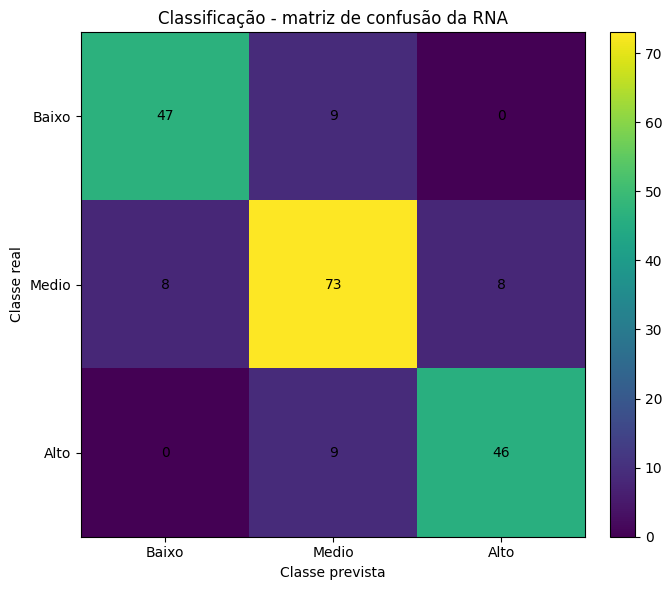

In [14]:
# 14. Matriz de confusão da classificação
cm = confusion_matrix(y_class_test, pred_class_rna, labels=ordem_classes)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)
ax.set_title('Classificação - matriz de confusão da RNA')
ax.set_xlabel('Classe prevista')
ax.set_ylabel('Classe real')
ax.set_xticks(range(len(ordem_classes)))
ax.set_xticklabels(ordem_classes)
ax.set_yticks(range(len(ordem_classes)))
ax.set_yticklabels(ordem_classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(IMG_DIR / '05_classificacao_matriz_confusao.png', dpi=160)
plt.show()

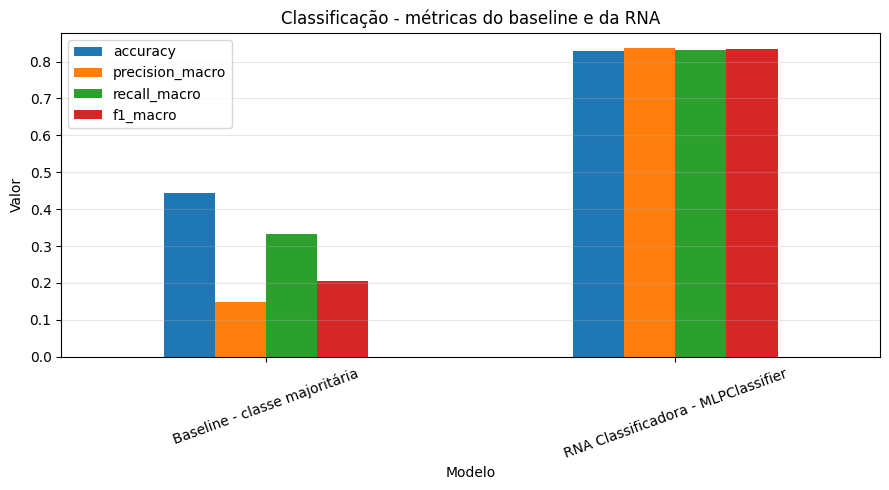

In [15]:
# 15. Comparação de métricas da classificação
ax = metricas_classificacao.set_index('modelo')[
    ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
].plot(kind='bar', figsize=(9, 5))

plt.title('Classificação - métricas do baseline e da RNA')
plt.xlabel('Modelo')
plt.ylabel('Valor')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '06_classificacao_comparacao_metricas.png', dpi=160)
plt.show()

# Parte B - RNA para regressão

Nesta parte, a RNA será usada como **regressora**. O alvo é `exam_score`, ou seja, a nota numérica do aluno.

Aqui a saída esperada do modelo é um número, por exemplo: `78.6`.

Nesta parte **não há conversão para classe**. O objetivo é prever diretamente a nota.

In [16]:
# 16. Modelo de regressão com RNA
rna_regressora = Pipeline(steps=[
    ('preprocessamento', criar_preprocessador()),
    ('modelo', MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        batch_size=32,
        random_state=RANDOM_STATE
    ))
])

baseline_regressao = DummyRegressor(strategy='mean')

baseline_regressao.fit(X_train, y_reg_train)
rna_regressora.fit(X_train, y_reg_train)

pred_reg_baseline = baseline_regressao.predict(X_test)
pred_reg_rna = rna_regressora.predict(X_test)

# Como exam_score está no intervalo de 0 a 100, limitamos previsões fora desse intervalo.
pred_reg_rna = np.clip(pred_reg_rna, 0, 100)

print('Treinamento da RNA regressora concluído.')

Treinamento da RNA regressora concluído.


In [17]:
# 17. Métricas da regressão

def calcular_metricas_regressao(nome, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'modelo': nome,
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred)
    }

metricas_regressao = pd.DataFrame([
    calcular_metricas_regressao('Baseline - média do treino', y_reg_test, pred_reg_baseline),
    calcular_metricas_regressao('RNA Regressora - MLPRegressor', y_reg_test, pred_reg_rna)
])

metricas_regressao.to_csv('metricas_regressao.csv', index=False)
metricas_regressao

,modelo,MAE,MSE,RMSE,R2
0,Baseline - média do treino,13.476905,270.195759,16.437632,-0.000509
1,RNA Regressora - MLPRegressor,4.015486,26.652349,5.162591,0.901309


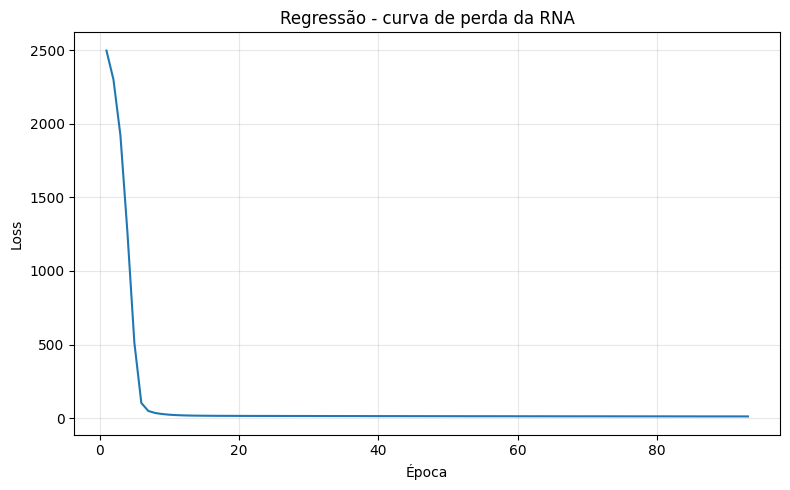

In [18]:
# 18. Curva de perda da regressão
loss_regressao = rna_regressora.named_steps['modelo'].loss_curve_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_regressao) + 1), loss_regressao)
plt.title('Regressão - curva de perda da RNA')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '07_regressao_curva_perda.png', dpi=160)
plt.show()

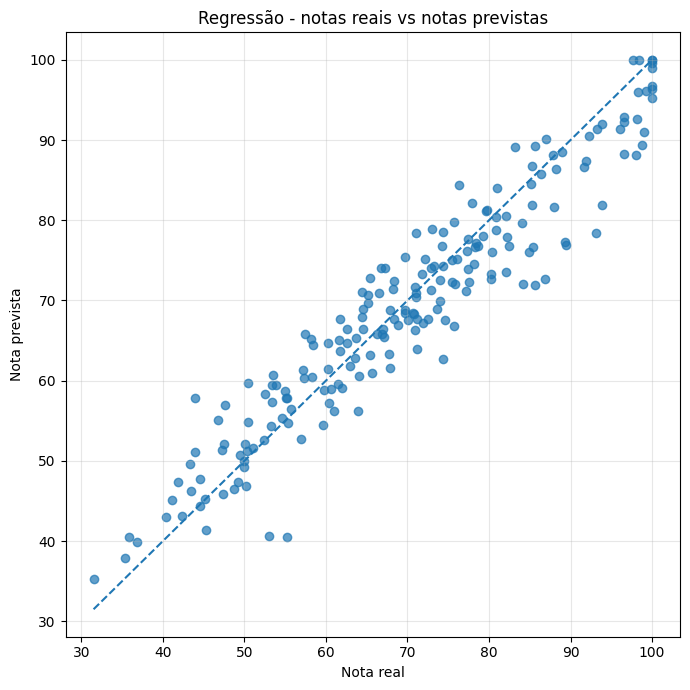

In [19]:
# 19. Gráfico de notas reais vs notas previstas
plt.figure(figsize=(7, 7))
plt.scatter(y_reg_test, pred_reg_rna, alpha=0.7)

min_v = min(float(y_reg_test.min()), float(pred_reg_rna.min()))
max_v = max(float(y_reg_test.max()), float(pred_reg_rna.max()))
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')

plt.title('Regressão - notas reais vs notas previstas')
plt.xlabel('Nota real')
plt.ylabel('Nota prevista')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '08_regressao_real_vs_previsto.png', dpi=160)
plt.show()

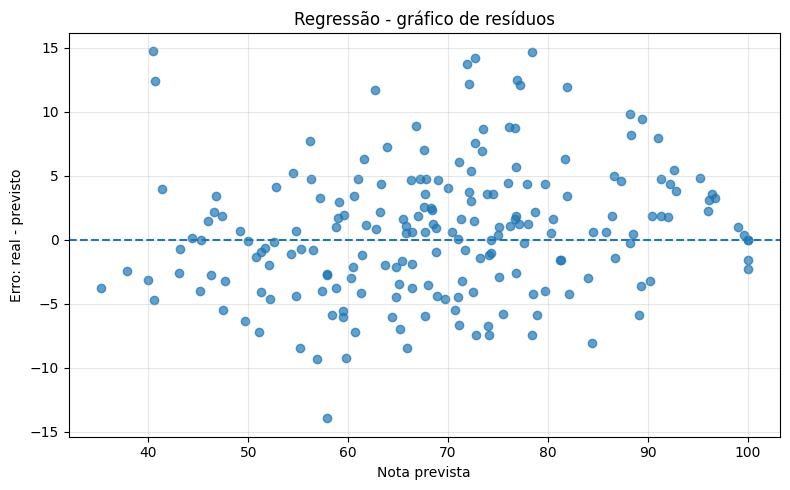

In [20]:
# 20. Gráfico de resíduos
residuos = y_reg_test.values - pred_reg_rna

plt.figure(figsize=(8, 5))
plt.scatter(pred_reg_rna, residuos, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.title('Regressão - gráfico de resíduos')
plt.xlabel('Nota prevista')
plt.ylabel('Erro: real - previsto')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '09_regressao_residuos.png', dpi=160)
plt.show()

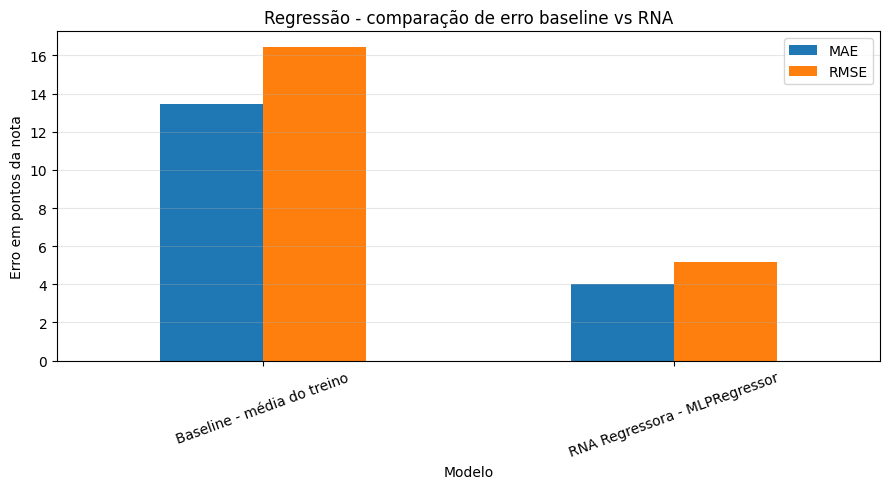

In [21]:
# 21. Comparação do erro entre baseline e RNA
ax = metricas_regressao.set_index('modelo')[['MAE', 'RMSE']].plot(kind='bar', figsize=(9, 5))

plt.title('Regressão - comparação de erro baseline vs RNA')
plt.xlabel('Modelo')
plt.ylabel('Erro em pontos da nota')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '10_regressao_comparacao_erro.png', dpi=160)
plt.show()

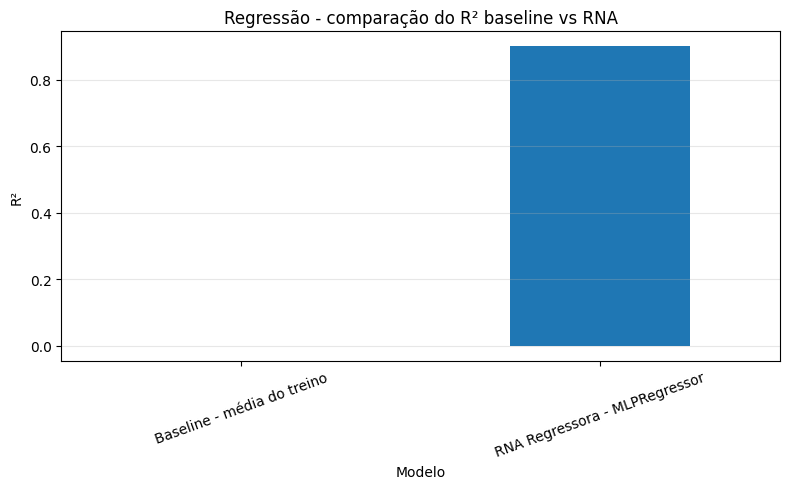

In [22]:
# 22. Comparação do R² entre baseline e RNA
ax = metricas_regressao.set_index('modelo')[['R2']].plot(kind='bar', figsize=(8, 5), legend=False)

plt.title('Regressão - comparação do R² baseline vs RNA')
plt.xlabel('Modelo')
plt.ylabel('R²')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '11_regressao_comparacao_r2.png', dpi=160)
plt.show()

# Salvamento dos modelos e previsões

São salvos dois modelos separados:

- `rna_classificadora_score_class.joblib`: modelo de classificação.
- `rna_regressora_exam_score.joblib`: modelo de regressão.

In [23]:
# 23. Salvamento dos modelos treinados e das previsões de teste
joblib.dump(rna_classificadora, MODEL_DIR / 'rna_classificadora_score_class.joblib')
joblib.dump(rna_regressora, MODEL_DIR / 'rna_regressora_exam_score.joblib')

previsoes_teste = X_test.copy()
previsoes_teste['score_class_real'] = y_class_test.values
previsoes_teste['score_class_prevista_rna'] = pred_class_rna
previsoes_teste['exam_score_real'] = y_reg_test.values
previsoes_teste['exam_score_previsto_rna'] = pred_reg_rna
previsoes_teste['erro_regressao'] = previsoes_teste['exam_score_real'] - previsoes_teste['exam_score_previsto_rna']
previsoes_teste['erro_absoluto_regressao'] = previsoes_teste['erro_regressao'].abs()

previsoes_teste.to_csv('previsoes_teste.csv', index=False)
previsoes_teste.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,score_class_real,score_class_prevista_rna,exam_score_real,exam_score_previsto_rna,erro_regressao,erro_absoluto_regressao
749,18,Female,3.7,4.0,1.0,No,70.1,6.7,Good,0,Bachelor,Poor,9,Yes,Medio,Medio,77.2,71.121117,6.078883,6.078883
808,22,Male,3.2,0.3,4.0,Yes,67.3,5.3,Good,3,High School,Good,1,No,Baixo,Baixo,43.9,57.844874,-13.944874,13.944874
477,24,Male,4.1,3.6,2.2,No,93.8,6.9,Poor,5,High School,Poor,8,No,Alto,Medio,84.0,79.676420,4.323580,4.323580
767,24,Male,3.1,2.8,2.3,No,79.0,4.8,Poor,0,Bachelor,Average,10,No,Medio,Medio,63.7,65.346119,-1.646119,1.646119
503,24,Female,2.6,1.4,2.1,Yes,84.4,7.1,Fair,0,High School,Average,7,No,Medio,Baixo,63.0,61.812706,1.187294,1.187294


In [24]:
# 24. Metadados dos modelos
metadata = {
    'dataset': 'student_habits_performance.csv',
    'total_registros': int(len(df)),
    'treino_registros': int(len(X_train)),
    'teste_registros': int(len(X_test)),
    'preditores': X.columns.tolist(),
    'classificacao': {
        'objetivo': 'Prever score_class nominal: Baixo, Medio ou Alto.',
        'target': 'score_class',
        'origem_da_classe': 'score_class foi criado a partir de exam_score: Baixo < 60, Medio 60-79.99, Alto >= 80.',
        'modelo': 'MLPClassifier',
        'arquitetura': [64, 32],
        'metricas_rna': metricas_classificacao.iloc[1].to_dict()
    },
    'regressao': {
        'objetivo': 'Prever a nota numérica do aluno.',
        'target': 'exam_score',
        'modelo': 'MLPRegressor',
        'arquitetura': [64, 32],
        'metricas_rna': metricas_regressao.iloc[1].to_dict()
    },
    'observacao': 'Classificação e regressão são problemas diferentes. As métricas não devem ser comparadas diretamente.'
}

with open('metadata_modelos.json', 'w', encoding='utf-8') as arquivo:
    json.dump(metadata, arquivo, indent=2, ensure_ascii=False)

metadata

{'dataset': 'student_habits_performance.csv',
 'total_registros': 1000,
 'treino_registros': 800,
 'teste_registros': 200,
 'preditores': ['age',
  'gender',
  'study_hours_per_day',
  'social_media_hours',
  'netflix_hours',
  'part_time_job',
  'attendance_percentage',
  'sleep_hours',
  'diet_quality',
  'exercise_frequency',
  'parental_education_level',
  'internet_quality',
  'mental_health_rating',
  'extracurricular_participation'],
 'classificacao': {'objetivo': 'Prever score_class nominal: Baixo, Medio ou Alto.',
  'target': 'score_class',
  'origem_da_classe': 'score_class foi criado a partir de exam_score: Baixo < 60, Medio 60-79.99, Alto >= 80.',
  'modelo': 'MLPClassifier',
  'arquitetura': [64, 32],
  'metricas_rna': {'modelo': 'RNA Classificadora - MLPClassifier',
   'accuracy': 0.83,
   'precision_macro': 0.8361983695317029,
   'recall_macro': 0.8319580232501581,
   'f1_macro': 0.8339982184018883}},
 'regressao': {'objetivo': 'Prever a nota numérica do aluno.',
  'targ

# Conclusão

A RNA classificadora foi usada para prever uma categoria de desempenho (`Baixo`, `Medio` ou `Alto`). Para esse caso, as métricas adequadas são acurácia, precisão, revocação, F1-score e matriz de confusão.

A RNA regressora foi usada para prever diretamente a nota do aluno (`exam_score`). Para esse caso, as métricas adequadas são MAE, MSE, RMSE e R².

Portanto, os dois modelos aparecem no mesmo notebook para fins de estudo e comparação metodológica, mas cada um resolve um tipo de problema diferente.